<a href="https://colab.research.google.com/github/Gianluca-dot/Project-Deep-Learning-e-Reti-Neurali/blob/main/CNN_3_con_learning_rate_minore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PROCEDIAMO ALL'IMPORTAZIONE DELLE LIBRERIE CHE CI SERVONO

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    InputLayer,
    Dense,
    Dropout,
    Activation,
    Flatten,
    Conv2D,
    MaxPooling2D,
    BatchNormalization
)



OSSERVIAMO LA STRUTTURA DELLA CNN CHE VOGLIAMO CUSTOMIZZARE

In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16
model = VGG16()
model.summary()


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 25s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

CARICHIAMO IL DATASET CIFAR-10





In [ ]:
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print(" Dataset CIFAR-10 caricato correttamente")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 390s 2us/step
 Dataset CIFAR-10 caricato correttamente


CONTROLLO DELLE DIMENSIONI

In [ ]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


CLASSI CIFAR-10

In [ ]:
class_names = ['airplane',
               'automobile',
               'bird',
               'cat',
               'deer',
               'dog',
               'frog',
               'horse',
               'ship',
               'truck',
              ]
print("numero di classi: ", len(class_names))
print("classi CIFAR-10:")
for i, class_name in enumerate(class_names):
    print(i, "->", class_name)

numero di classi:  10
classi CIFAR-10:
0 -> airplane
1 -> automobile
2 -> bird
3 -> cat
4 -> deer
5 -> dog
6 -> frog
7 -> horse
8 -> ship
9 -> truck


IDENTIFICAZIONE ED ELIMINAZIONE DELLE CLASSI DA ESCLUDERE

In [ ]:
train_mask = (y_train.flatten() !=0) & (y_train.flatten() != 8)
test_mask = (y_test.flatten() !=0) & (y_test.flatten() != 8)
x_train_filtered = x_train[train_mask]
y_train_filtered = y_train[train_mask]
x_test_filtered = x_test[test_mask]
y_test_filtered = y_test[test_mask]

VERIFICA DEL DATASET FILTRATO

In [ ]:
print("x_train originale:", x_train.shape)
print("x_train filtrato:", x_train_filtered.shape)
print("y_test originale:", y_test.shape)
print("y_test filtrato:", y_test_filtered.shape)

x_train originale: (50000, 32, 32, 3)
x_train filtrato: (40000, 32, 32, 3)
y_test originale: (10000, 1)
y_test filtrato: (8000, 1)


CONVERSIONE DELLE CLASSI IN ANIMALE/VEICOLO

In [ ]:
animal_classes = [2,3,4,5,6,7,]
veicle_classes = [1,9]

y_train_binary = np.where(np.isin(y_train_filtered, animal_classes),0,1)
y_test_binary = np.where(np.isin(y_test_filtered, animal_classes) , 0, 1)
print("Classi train", np.unique(y_train_binary))
print("Classi test", np.unique(y_test_binary))

Classi train [0 1]
Classi test [0 1]


TRAIN / VALIDATION / TEST - SPLIT STRATIFICATO

In [ ]:
from sklearn.model_selection import train_test_split

# Split stratificato: 80% Training e 20% Validation
x_train, x_validation, y_train, y_validation = train_test_split(
    x_train_filtered,
    y_train_binary,
    test_size=0.20,
    stratify=y_train_binary,
    random_state=42
)

# Il Test set rimane completamente separato
x_test = x_test_filtered
y_test = y_test_binary


# Controllo delle dimensioni
print("Training:", x_train.shape)
print("Validation:", x_validation.shape)
print("Test:", x_test.shape)


# Controllo distribuzione Animale / Veicolo
print("\nDistribuzione classi:")

for nome, y in [("Training", y_train),
                ("Validation", y_validation),
                ("Test", y_test)]:

    animali = np.sum(y == 0)
    veicoli = np.sum(y == 1)

    print(nome,
          "→ Animali:", animali,
          "| Veicoli:", veicoli)


Training: (32000, 32, 32, 3)
Validation: (8000, 32, 32, 3)
Test: (8000, 32, 32, 3)

Distribuzione classi:
Training → Animali: 24000 | Veicoli: 8000
Validation → Animali: 6000 | Veicoli: 2000
Test → Animali: 6000 | Veicoli: 2000


NORMALIZZAZIONE

In [ ]:
from tensorflow.keras.layers import Rescaling

rescaling = Rescaling(1./255)

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.05),
    RandomZoom(0.10)
])

COSTRUZIONE DELLA CNN-1

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    InputLayer,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Activation,
    Dropout,
    GlobalAveragePooling2D,
    Dense
)

model = Sequential([

    # Input
    InputLayer(shape=(32, 32, 3)),

    # Normalizzazione
    Rescaling(1./255),

    # Data Augmentation - solo Training
    data_augmentation,

    # -------------------------
    # BLOCCO CONVOLUZIONALE 1
    # -------------------------
    Conv2D(32, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    Conv2D(32, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    MaxPooling2D(pool_size=(2, 2)),

    # -------------------------
    # BLOCCO CONVOLUZIONALE 2
    # -------------------------
    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    MaxPooling2D(pool_size=(2, 2)),

    # -------------------------
    # BLOCCO CONVOLUZIONALE 3
    # -------------------------
    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    Dropout(0.25),

    # -------------------------
    # CLASSIFICAZIONE
    # -------------------------
    GlobalAveragePooling2D(),

    Dense(64),
    Activation('relu'),

    Dropout(0.30),

    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,25

 Total params: 149,025 (582.13 KB)

 Trainable params: 148,385 (579.63 KB)

 Non-trainable params: 640 (2.50 KB)

COMPILAZIONE CNN-1

In [ ]:
model.compile(
    optimizer= tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ADDESTRAMENTO CNN-1

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    'CNN-1_best.keras',
    monitor='val_loss',
    save_best_only=True
)

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_validation, y_validation),
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.8989 - loss: 0.2503 - val_accuracy: 0.8520 - val_loss: 0.3535
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9308 - loss: 0.1801 - val_accuracy: 0.9457 - val_loss: 0.1419
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9402 - loss: 0.1597 - val_accuracy: 0.9006 - val_loss: 0.2346
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9466 - loss: 0.1447 - val_accuracy: 0.9183 - val_loss: 0.1941
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9519 - loss: 0.1332 - val_accuracy: 0.9379 - val_loss: 0.1562
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9532 - loss: 0.1275 - val_accuracy: 0.9620 - val_loss: 0.1041
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9563 - loss: 0.1181 - val_accuracy: 0.8903 - val_loss: 0.2518
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9591 - loss: 0.1129 - val_acc

ANALISI DEL TRAINING DELLA CNN-1

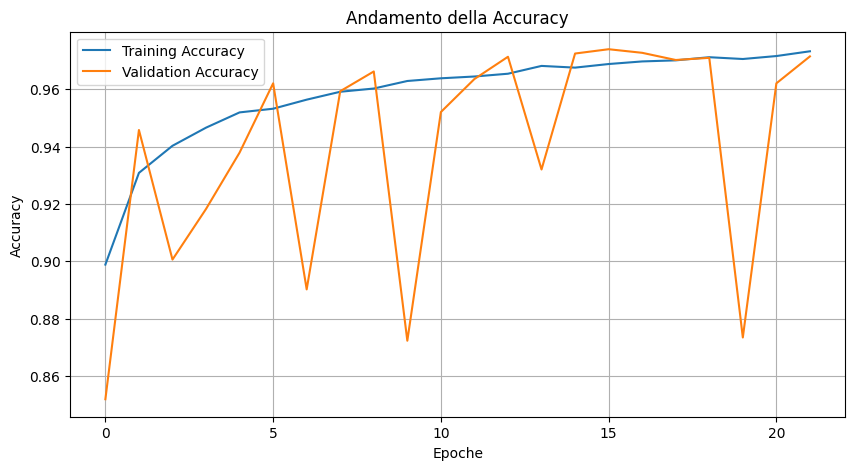

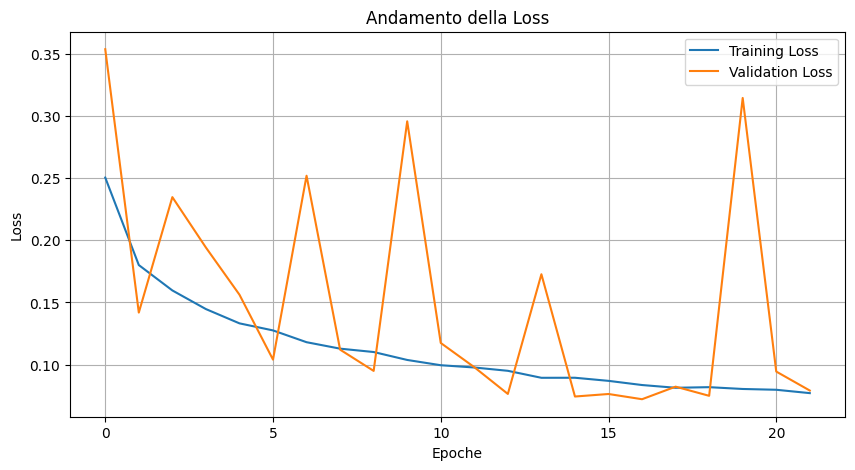

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(10, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Andamento della Accuracy')
plt.xlabel('Epoche')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


# Loss
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Andamento della Loss')
plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Migliore epoca in base alla Validation Loss
best_epoch = np.argmin(history.history['val_loss'])

print("Migliore epoca:", best_epoch + 1)
print("Training Accuracy:", history.history['accuracy'][best_epoch])
print("Validation Accuracy:", history.history['val_accuracy'][best_epoch])
print("Training Loss:", history.history['loss'][best_epoch])
print("Validation Loss:", history.history['val_loss'][best_epoch])

Migliore epoca: 17
Training Accuracy: 0.9696249961853027
Validation Accuracy: 0.9726250171661377
Training Loss: 0.08364768326282501
Validation Loss: 0.07224452495574951


VALUTAZIONE DEL TEST SET

In [ ]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("\nRisultati CNN-3:")
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9699 - loss: 0.0751

Risultati CNN-1:
Test Accuracy: 0.9698749780654907
Test Loss: 0.07508593052625656


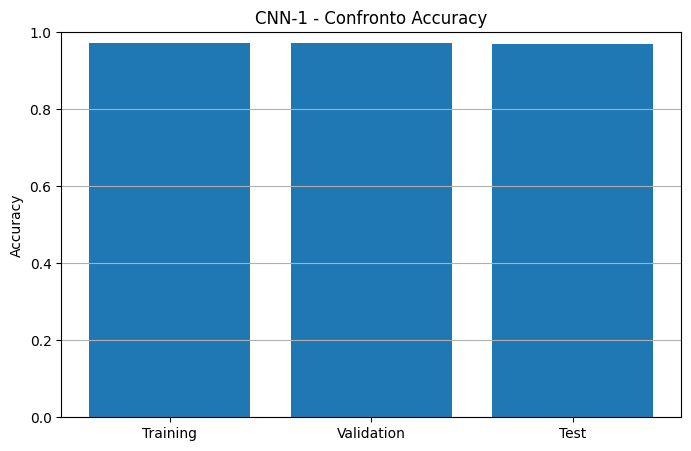

In [ ]:
# Confronto delle Accuracy

train_accuracy = history.history['accuracy'][-1]
validation_accuracy = history.history['val_accuracy'][-1]

accuracies = [
    train_accuracy,
    validation_accuracy,
    test_accuracy
]

labels = [
    'Training',
    'Validation',
    'Test'
]

plt.figure(figsize=(8, 5))

plt.bar(labels, accuracies)

plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('CNN-1 - Confronto Accuracy')
plt.grid(axis='y')

plt.show()

MATRICE DI CONFUSIONE

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


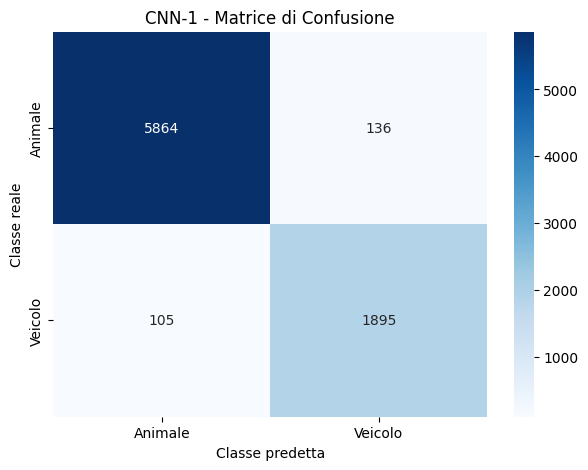

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Predizioni sul Test Set
y_pred = model.predict(x_test)

# Conversione delle probabilità in classi 0/1
y_pred = (y_pred >= 0.5).astype(int).flatten()

# Etichette reali
y_true = y_test.flatten()

# Matrice di confusione
cm = confusion_matrix(y_true, y_pred)

# Visualizzazione
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Animale', 'Veicolo'],
    yticklabels=['Animale', 'Veicolo']
)

plt.xlabel('Classe predetta')
plt.ylabel('Classe reale')
plt.title('CNN-1 - Matrice di Confusione')

plt.show()

PRECISION RECALL F1-SCORE

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Animale = classe 0
precision_animale = precision_score(y_true, y_pred, pos_label=0)
recall_animale = recall_score(y_true, y_pred, pos_label=0)
f1_animale = f1_score(y_true, y_pred, pos_label=0)

# Veicolo = classe 1
precision_veicolo = precision_score(y_true, y_pred, pos_label=1)
recall_veicolo = recall_score(y_true, y_pred, pos_label=1)
f1_veicolo = f1_score(y_true, y_pred, pos_label=1)

print("=== ANIMALE ===")
print("Precision:", precision_animale)
print("Recall:", recall_animale)
print("F1-score:", f1_animale)

print("\n=== VEICOLO ===")
print("Precision:", precision_veicolo)
print("Recall:", recall_veicolo)
print("F1-score:", f1_veicolo)

=== ANIMALE ===
Precision: 0.9824091137543978
Recall: 0.9773333333333334
F1-score: 0.9798646503467291

=== VEICOLO ===
Precision: 0.9330379123584441
Recall: 0.9475
F1-score: 0.940213346564128
